# 03 Model Evaluation

Notebook นี้เปรียบเทียบ **ทุก models** (Baseline + Advanced) และวิเคราะห์:
- Metrics summary table
- Residual plots
- Feature Importance
- SHAP analysis (best model)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

MODEL_DIR  = Path('../../models')
FIGURE_DIR = Path('../../reports/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'total_time_min'
RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


## Load Data & Models

In [2]:
TARGET = 'total_time_min'

train_df = pd.read_csv('../../data/processed/train.csv', encoding='utf-8-sig')
test_df  = pd.read_csv('../../data/processed/test.csv',  encoding='utf-8-sig')

feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET]
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET]

# Drop non-numeric & fill missing
non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric: {non_numeric}')
    X_train = X_train.drop(columns=non_numeric)
    X_test  = X_test.drop(columns=non_numeric)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

print(f'Features : {len(X_train.columns)}')
print(f'Train : X={X_train.shape}  y={y_train.shape}')
print(f'Test  : X={X_test.shape}   y={y_test.shape}')

Features : 26
Train : X=(17668, 26)  y=(17668,)
Test  : X=(4417, 26)   y=(4417,)


In [3]:
model_files = {
    'Baseline (best)' : MODEL_DIR / 'baseline_best_totaltime.joblib',
    'RF (tuned)'      : MODEL_DIR / 'rf_tuned_totaltime.joblib',
    'XGBoost (Optuna)': MODEL_DIR / 'xgb_tuned_totaltime.joblib',
    'LightGBM (Optuna)': MODEL_DIR / 'lgb_tuned_totaltime.joblib',
    'CatBoost (Optuna)': MODEL_DIR / 'cat_tuned_totaltime.joblib',
}

models = {}
for name, path in model_files.items():
    if path.exists():
        models[name] = joblib.load(path)
        print(f'Loaded : {name}')
    else:
        print(f'Missing: {name} ({path})')

Loaded : Baseline (best)
Loaded : RF (tuned)
Loaded : XGBoost (Optuna)
Loaded : LightGBM (Optuna)
Loaded : CatBoost (Optuna)


## Metrics Summary

In [4]:
def get_metrics(name, model, X_tr, y_tr, X_te, y_te):
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    return {
        'Model'      : name,
        'Train MAE'  : round(mean_absolute_error(y_tr, p_tr), 2),
        'Test MAE'   : round(mean_absolute_error(y_te, p_te), 2),
        'Train RMSE' : round(np.sqrt(mean_squared_error(y_tr, p_tr)), 3),
        'Test RMSE'  : round(np.sqrt(mean_squared_error(y_te, p_te)), 2),
        'Train R²'   : round(r2_score(y_tr, p_tr), 2),
        'Test R²'    : round(r2_score(y_te, p_te), 2),
        'Overfit Gap': round(r2_score(y_tr, p_tr) - r2_score(y_te, p_te), 2),
    }

rows = [get_metrics(n, m, X_train, y_train, X_test, y_test) for n, m in models.items()]
metrics_df = pd.DataFrame(rows).sort_values('Test RMSE').reset_index(drop=True)

display_cols = ['Model', 'Test MAE', 'Test RMSE', 'Test R²', 'Train R²', 'Overfit Gap']
print(metrics_df[display_cols].to_string(index=False))

            Model  Test MAE  Test RMSE  Test R²  Train R²  Overfit Gap
 XGBoost (Optuna)     11.43      14.47     0.55      0.69         0.13
LightGBM (Optuna)     11.44      14.49     0.55      0.67         0.11
CatBoost (Optuna)     11.52      14.54     0.55      0.67         0.12
       RF (tuned)     11.59      14.65     0.54      0.80         0.25
  Baseline (best)     12.07      15.21     0.51      0.52         0.01


## Before vs After — Outlier Cleaning (Level 1 + Level 2)

เปรียบเทียบ metrics **ก่อน** และ **หลัง** เพิ่ม outlier rules:
- **Level 1A**: phase domain thresholds (wait/prepare/close)
- **Level 1B**: `loading_time_min` threshold แยกตาม CarType (4W/6W/10W/Trailer)
- **Level 2**: `total_time_min` > 200 min direct cut

| เงื่อนไข | Before | After |
|---|---|---|
| Train samples | 38,011 | 37,492 |
| Test samples | 9,503 | 9,374 |
| target std | 38.0 min | 34.1 min |
| target max | 506.9 min | 199.9 min |


=== Before vs After — Outlier Level 1 + Level 2 ===
            Model  RMSE Before  RMSE After  RMSE Delta  MAE Before  MAE After  MAE Delta  R2 Before  R2 After  R2 Delta
 XGBoost (Optuna)        23.47       14.47       -9.00       17.10      11.43      -5.67       0.62      0.55     -0.07
LightGBM (Optuna)        23.53       14.49       -9.04       17.14      11.44      -5.70       0.62      0.55     -0.07
CatBoost (Optuna)        23.46       14.54       -8.92       17.11      11.52      -5.59       0.62      0.55     -0.07
       RF (tuned)        24.00       14.65       -9.35       17.54      11.59      -5.95       0.60      0.54     -0.06
  Baseline (best)        27.08       15.21      -11.87       20.02      12.07      -7.95       0.49      0.51      0.02


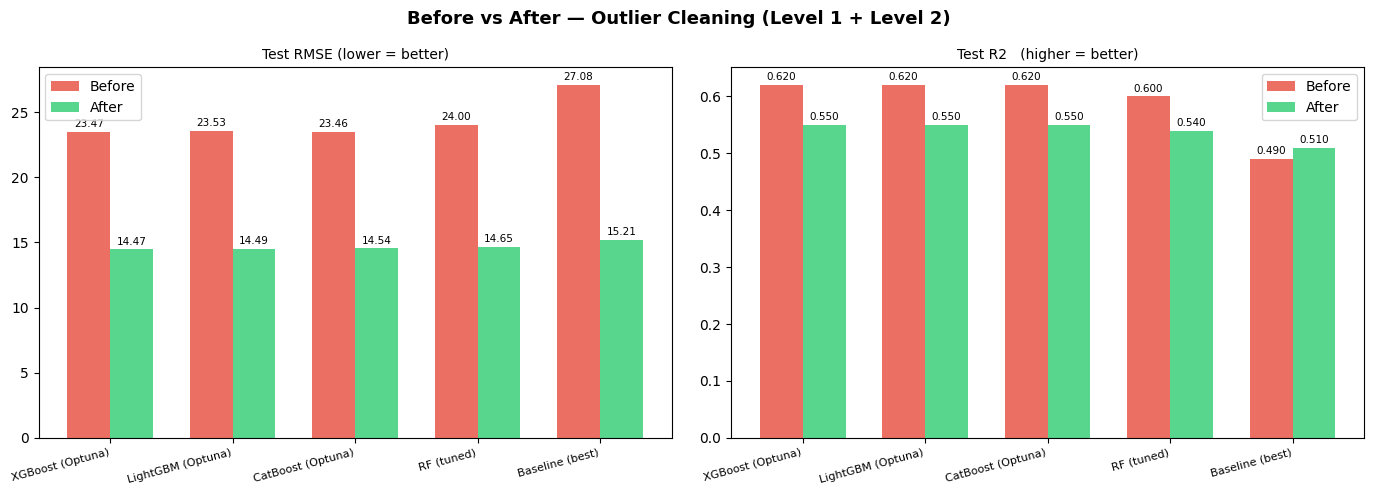

Figure saved: before_after_comparison.png


In [5]:
# ── Before vs After comparison (hardcoded baseline = pre-outlier-L1L2 run) ──
BEFORE = {
    'Baseline (best)' : {'RMSE': 27.08, 'MAE': 20.02, 'R2': 0.49},
    'RF (tuned)'       : {'RMSE': 24.00, 'MAE': 17.54, 'R2': 0.60},
    'XGBoost (Optuna)' : {'RMSE': 23.47, 'MAE': 17.10, 'R2': 0.62},
    'LightGBM (Optuna)': {'RMSE': 23.53, 'MAE': 17.14, 'R2': 0.62},
    'CatBoost (Optuna)': {'RMSE': 23.46, 'MAE': 17.11, 'R2': 0.62},
}

compare_rows = []
for _, row in metrics_df.iterrows():
    name = row['Model']
    bef  = BEFORE.get(name, {})
    compare_rows.append({
        'Model'        : name,
        'RMSE Before'  : bef.get('RMSE', '-'),
        'RMSE After'   : row['Test RMSE'],
        'RMSE Delta'   : round(row['Test RMSE'] - bef['RMSE'], 2) if bef else '-',
        'MAE Before'   : bef.get('MAE', '-'),
        'MAE After'    : row['Test MAE'],
        'MAE Delta'    : round(row['Test MAE'] - bef['MAE'], 2) if bef else '-',
        'R2 Before'    : bef.get('R2', '-'),
        'R2 After'     : row['Test R²'],
        'R2 Delta'     : round(row['Test R²'] - bef['R2'], 3) if bef else '-',
    })

compare_df = pd.DataFrame(compare_rows)
print('=== Before vs After — Outlier Level 1 + Level 2 ===')
print(compare_df.to_string(index=False))

# ── Plot: RMSE and R2 before/after ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Before vs After — Outlier Cleaning (Level 1 + Level 2)', fontsize=13, fontweight='bold')

model_names = compare_df['Model'].tolist()
x = np.arange(len(model_names))
w = 0.35

for ax, (metric_before, metric_after, title, fmt) in zip(axes, [
    ('RMSE Before', 'RMSE After', 'Test RMSE (lower = better)', '{:.2f}'),
    ('R2 Before',   'R2 After',   'Test R2   (higher = better)', '{:.3f}'),
]):
    b1 = ax.bar(x - w/2, compare_df[metric_before], w, label='Before', color='#e74c3c', alpha=0.8)
    b2 = ax.bar(x + w/2, compare_df[metric_after],  w, label='After',  color='#2ecc71', alpha=0.8)
    ax.bar_label(b1, fmt=fmt, padding=2, fontsize=7.5)
    ax.bar_label(b2, fmt=fmt, padding=2, fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.legend()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'before_after_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved: before_after_comparison.png')


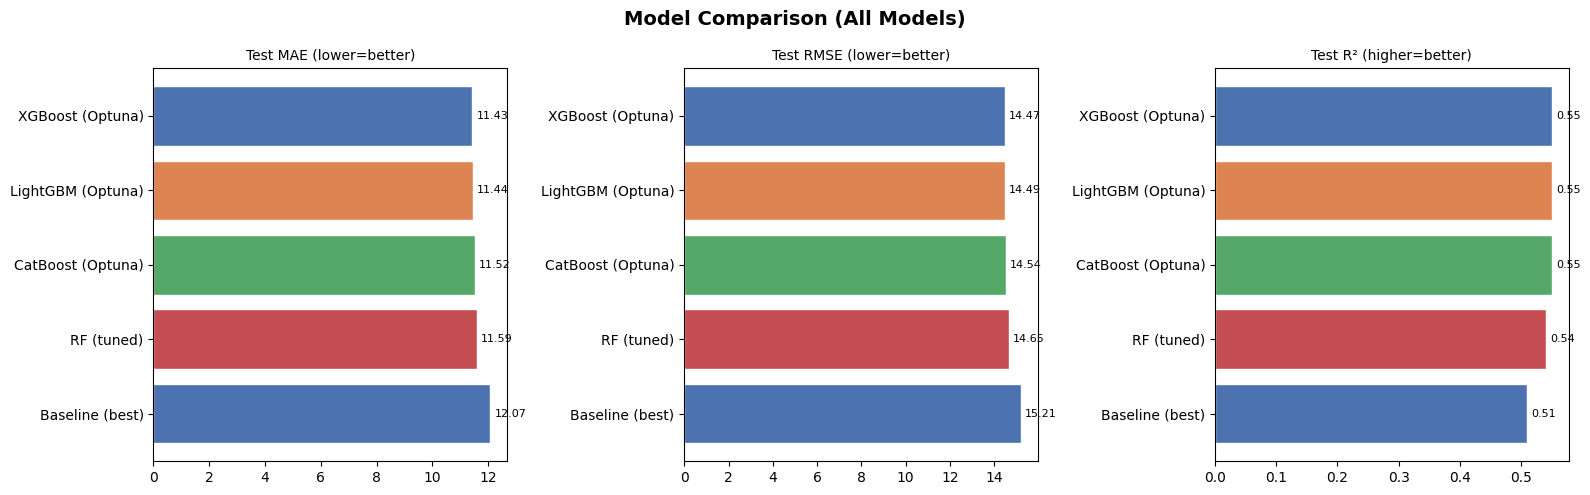

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison (All Models)', fontsize=14, fontweight='bold')
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (col, title) in zip(axes, [
    ('Test MAE',  'Test MAE (lower=better)'),
    ('Test RMSE', 'Test RMSE (lower=better)'),
    ('Test R²',   'Test R² (higher=better)'),
]):
    bars = ax.barh(metrics_df['Model'], metrics_df[col],
                   color=palette[:len(metrics_df)], edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'all_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Residual Analysis — Best Model

Best model : XGBoost (Optuna)


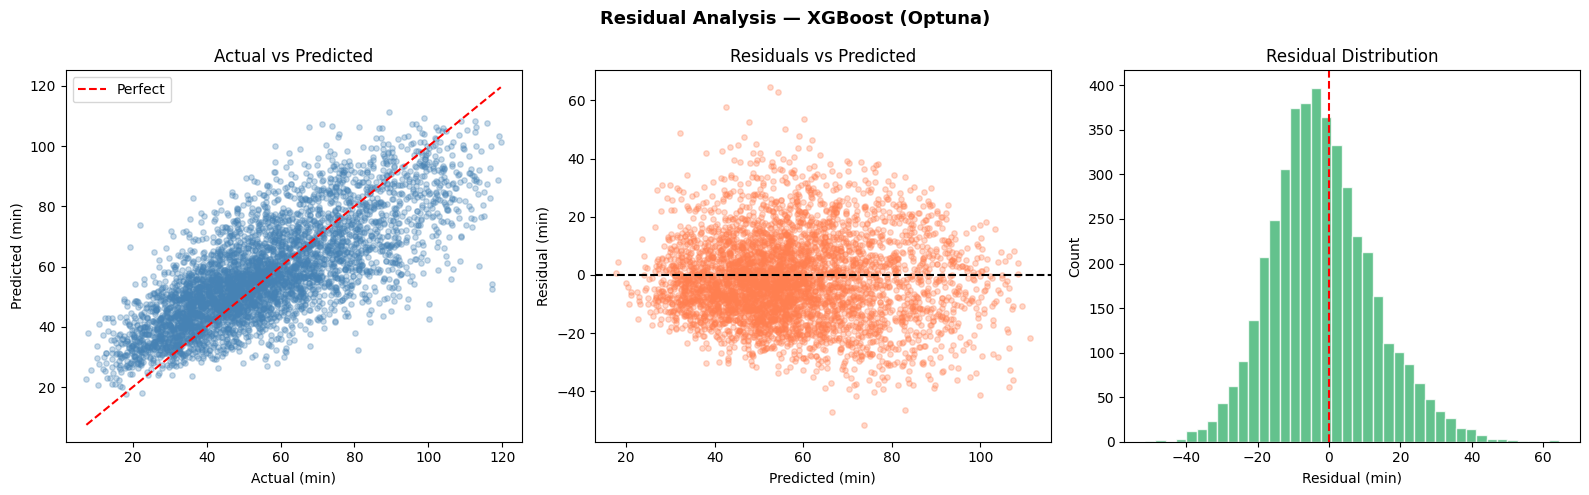

Mean residual : -1.7641 min
Std  residual : 14.3594 min


In [7]:
# เลือก best model
best_name  = metrics_df.iloc[0]['Model']
best_model = models[best_name]
print(f'Best model : {best_name}')

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel('Actual (min)')
ax.set_ylabel('Predicted (min)')
ax.set_title('Actual vs Predicted')
ax.legend()

# Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.3, s=15, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Predicted (min)')
ax.set_ylabel('Residual (min)')
ax.set_title('Residuals vs Predicted')

# Residual distribution
ax = axes[2]
ax.hist(residuals, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.set_xlabel('Residual (min)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'residual_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean residual : {residuals.mean():.4f} min')
print(f'Std  residual : {residuals.std():.4f} min')

## Feature Importance — Best Model

Feature Importance (avg % across tree models)
                   Feature  XGBoost (Optuna)  LightGBM (Optuna)  CatBoost (Optuna)  Avg %  Corr  CumSum %
          total_sap_amount             18.30               6.44              15.34  13.36  0.62     55.40
            car_type_x_sap             12.17               4.53              11.33   9.34  0.60     93.30
      total_fitting_amount              6.17               6.17              10.49   7.61  0.33     37.60
         total_tile_amount              6.93               5.11               5.58   5.87  0.58     30.00
       product_group_count             10.32               1.80               4.55   5.56  0.22     60.90
          PostLocationName              3.33               4.93               6.95   5.07  0.04     15.70
    rolling_avg_time_last5              1.37               8.20               4.82   4.80  0.11     80.50
  total_accessories_amount              2.45               6.11               4.65   4.40  0.09     42.00


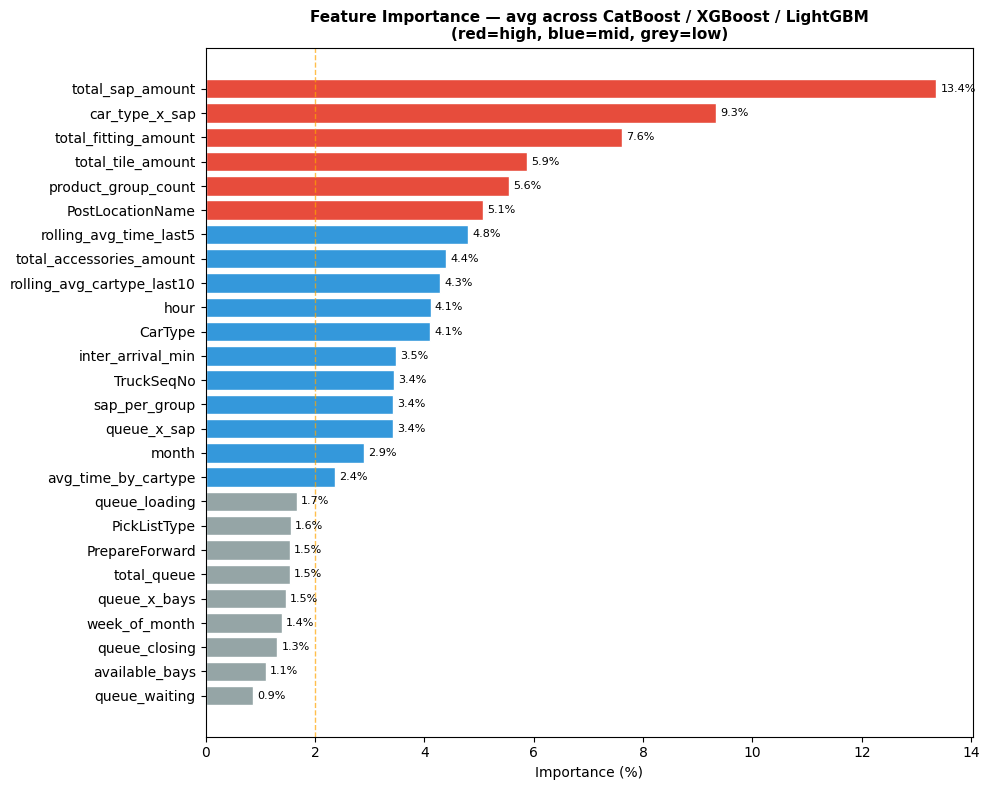

Figure saved


In [8]:
# Average feature importance across tree-based models
tree_models = {n: m for n, m in models.items() if n != 'Baseline (best)' and n != 'RF (tuned)'}

fi_all = pd.DataFrame({'Feature': X_train.columns})
for name, model in tree_models.items():
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        imp = model.get_feature_importance()
    else:
        continue
    fi_all[name] = imp / imp.sum() * 100

model_cols = list(tree_models.keys())
fi_all['Avg %']    = fi_all[model_cols].mean(axis=1)
fi_all['Corr']     = [round(float(X_train[c].corr(y_train)), 3) for c in fi_all['Feature']]
fi_all['CumSum %'] = fi_all['Avg %'].cumsum().round(1)
fi_all = fi_all.sort_values('Avg %', ascending=False).reset_index(drop=True)

print('Feature Importance (avg % across tree models)')
print(fi_all[['Feature'] + model_cols + ['Avg %', 'Corr', 'CumSum %']].to_string(
    index=False, float_format=lambda x: f'{x:.2f}'))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v >= 5 else '#3498db' if v >= 2 else '#95a5a6'
          for v in fi_all['Avg %']]
bars = ax.barh(fi_all['Feature'][::-1], fi_all['Avg %'][::-1],
               color=colors[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xlabel('Importance (%)')
ax.set_title('Feature Importance — avg across CatBoost / XGBoost / LightGBM\n'
             '(red=high, blue=mid, grey=low)', fontsize=11, fontweight='bold')
ax.axvline(2, color='orange', ls='--', lw=1, alpha=0.7, label='2% threshold')
plt.tight_layout()
fig.savefig(FIGURE_DIR / 'feature_importance_avg.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved')

## SHAP Analysis — Best Model

ใช้ SHAP เพื่อ interpret model — ว่า feature ไหนมีผลต่อการ predict มากแค่ไหน

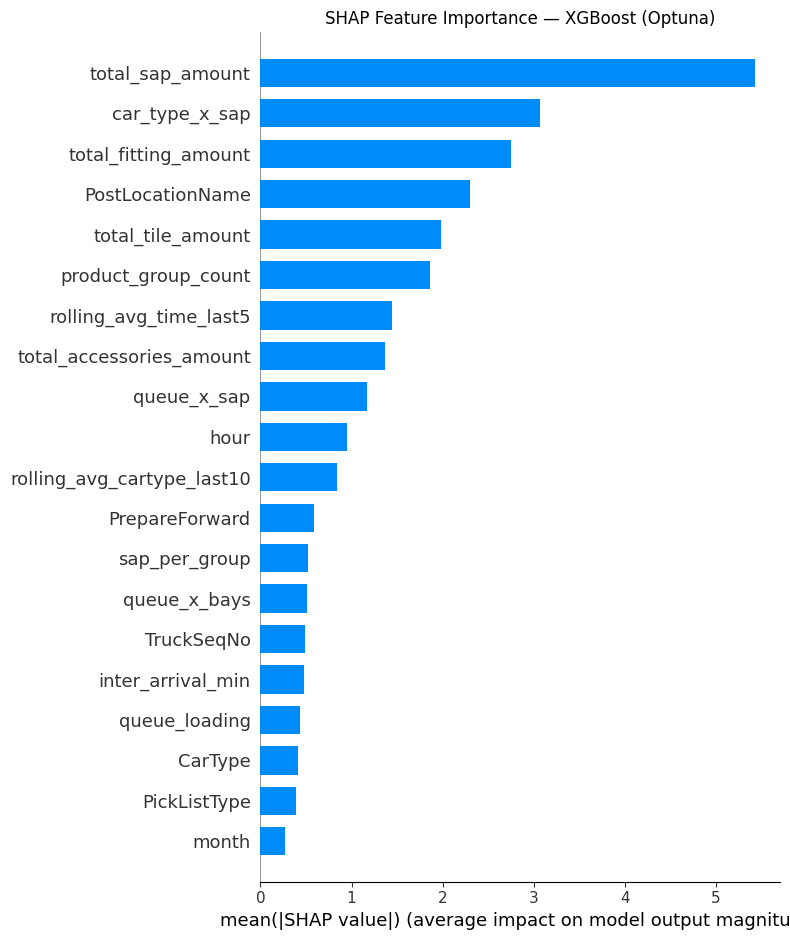

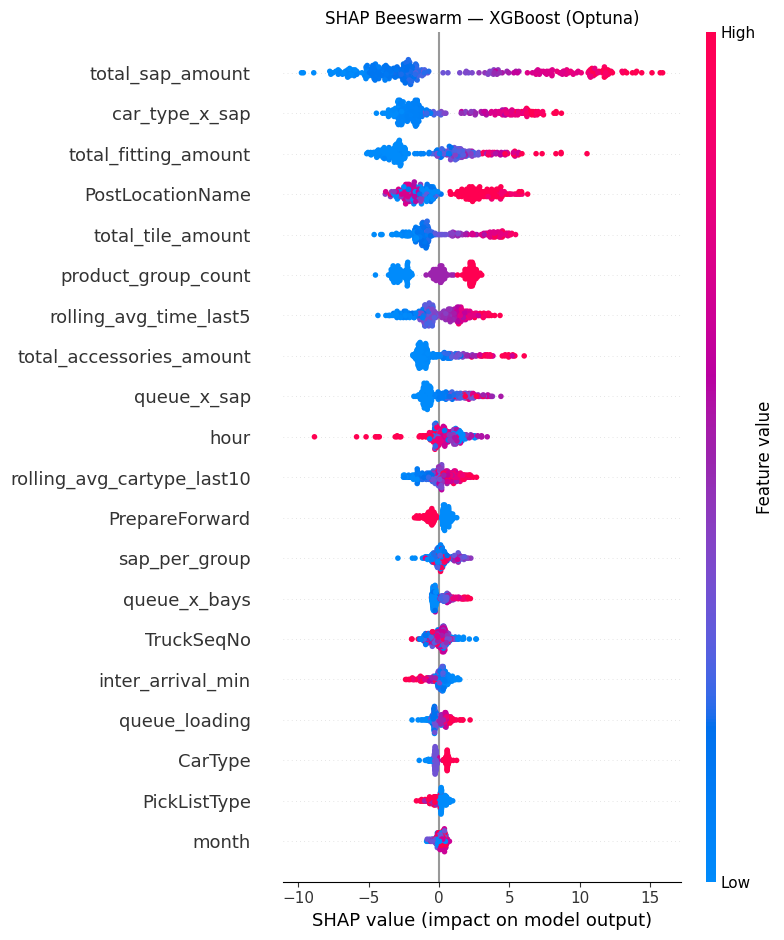

SHAP analysis done ✓


In [9]:
try:
    import shap
    shap.initjs()

    # ใช้ TreeExplainer สำหรับ tree models
    explainer = shap.TreeExplainer(best_model)
    
    # Sample 300 rows เพื่อความเร็ว
    X_sample = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance — {best_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'shap_summary_bar.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Beeswarm plot
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title(f'SHAP Beeswarm — {best_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('SHAP analysis done ✓')

except ImportError:
    print('shap not installed. Run: pip install shap')
except Exception as e:
    print(f'SHAP error (model may not support TreeExplainer): {e}')

## Error Analysis: Where Does the Model Fail?

=== Error Analysis — XGBoost (Optuna) ===
Test samples : 4,417

Error distribution:
count    4417.00
mean       11.43
std         8.87
min         0.00
25%         4.45
50%         9.53
75%        16.28
max        64.57
Name: abs_error, dtype: float64

Error buckets:
  0-5 min      : 1221 rows  ( 27.6%)
  5-10 min     : 1086 rows  ( 24.6%)
  10-15 min    :  838 rows  ( 19.0%)
  15-30 min    : 1091 rows  ( 24.7%)
  >30 min      :  181 rows  (  4.1%)

Error <= 10 min : 52.2%  (เป้าหมาย: สูง)
Error > 30 min  : 4.1%  (เป้าหมาย: ต่ำ)


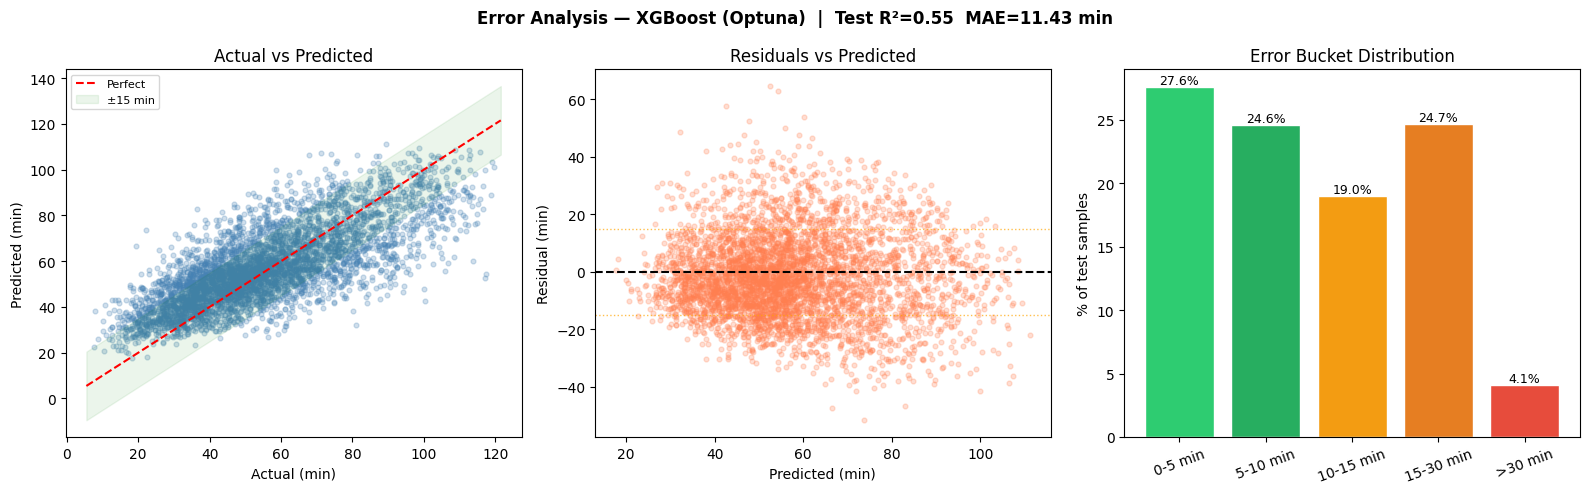


Top 10 worst predictions:
      actual  predicted  abs_error  pct_error
644   117.12  52.549999      64.57       55.1
2442  117.30  54.389999      62.91       53.6
654   100.28  42.580002      57.70       57.5
292   113.72  60.080002      53.64       47.2
1367  100.13  47.660000      52.47       52.4
2599   22.08  73.669998      51.59      233.7
1992  106.05  55.930000      50.12       47.3
1118   81.00  32.270000      48.73       60.2
1614  106.73  59.049999      47.68       44.7
2047   94.23  46.650002      47.58       50.5

Top 10 best predictions:
      actual   predicted  abs_error  pct_error
2173   30.70   30.700001       0.00        0.0
732    67.52   67.519997       0.00        0.0
3799   75.60   75.589996       0.01        0.0
92     49.18   49.169998       0.01        0.0
1261   40.27   40.290001       0.02        0.0
870    58.13   58.150002       0.02        0.0
1525   63.52   63.540001       0.02        0.0
2222   91.45   91.419998       0.03        0.0
3081   76.17   76.

In [10]:
best_name  = metrics_df.iloc[0]['Model']
best_model = models[best_name]
y_pred     = best_model.predict(X_test)

y_pred_s = pd.Series(y_pred, index=y_test.index)
err_df = pd.DataFrame({
    'actual'   : y_test,
    'predicted': y_pred_s,
    'abs_error': (y_test - y_pred_s).abs(),
    'residual' : y_test - y_pred_s,
})
err_df['pct_error'] = (err_df['abs_error'] / err_df['actual'] * 100).round(1)

# Error buckets
buckets = [0, 5, 10, 15, 30, np.inf]
labels  = ['0-5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
err_df['bucket'] = pd.cut(err_df['abs_error'], bins=buckets, labels=labels)
bucket_summary = err_df['bucket'].value_counts().reindex(labels)
bucket_pct     = (bucket_summary / len(err_df) * 100).round(1)

print(f'=== Error Analysis — {best_name} ===')
print(f'Test samples : {len(err_df):,}')
print()
print('Error distribution:')
print(err_df['abs_error'].describe().round(2))
print()
print('Error buckets:')
for lbl, cnt, pct in zip(labels, bucket_summary, bucket_pct):
    print(f'  {lbl:<12} : {cnt:>4} rows  ({pct:>5.1f}%)')

print()
good_pct  = bucket_pct.iloc[0] + bucket_pct.iloc[1]
print(f'Error <= 10 min : {good_pct:.1f}%  (เป้าหมาย: สูง)')
print(f'Error > 30 min  : {bucket_pct.iloc[4]:.1f}%  (เป้าหมาย: ต่ำ)')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Error Analysis — {best_name}  |  Test R²={metrics_df.iloc[0]["Test R²"]:.2f}  MAE={metrics_df.iloc[0]["Test MAE"]:.2f} min',
             fontsize=12, fontweight='bold')

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.25, s=12, color='steelblue')
lim = [min(y_test.min(), y_pred.min())-2, max(y_test.max(), y_pred.max())+2]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax.fill_between(lim, [l-15 for l in lim], [l+15 for l in lim], alpha=0.08, color='green', label='±15 min')
ax.set_xlabel('Actual (min)'); ax.set_ylabel('Predicted (min)')
ax.set_title('Actual vs Predicted'); ax.legend(fontsize=8)

# Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, err_df['residual'], alpha=0.25, s=12, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.axhline(15, color='orange', lw=1, ls=':', alpha=0.7)
ax.axhline(-15, color='orange', lw=1, ls=':', alpha=0.7)
ax.set_xlabel('Predicted (min)'); ax.set_ylabel('Residual (min)')
ax.set_title('Residuals vs Predicted')

# Error bucket bar
ax = axes[2]
colors_b = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
bars = ax.bar(labels, bucket_pct, color=colors_b, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', fontsize=9)
ax.set_ylabel('% of test samples')
ax.set_title('Error Bucket Distribution')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 worst predictions:')
worst = err_df.nlargest(10, 'abs_error')[['actual','predicted','abs_error','pct_error']]
print(worst.round(2).to_string())


print('\nTop 10 best predictions:')
best = err_df.nsmallest(100, 'abs_error')[['actual','predicted','abs_error','pct_error']]
print(best.round(2).to_string())

## Final Report

In [11]:
best_row   = metrics_df.iloc[0]
dummy_rmse = 24.395   # DummyRegressor mean baseline (ข้อมูลก่อน clean)

# ── Before vs After reference ────────────────────────────────────────────────
BEFORE_BEST_RMSE = 23.46   # CatBoost ก่อน outlier L1+L2
BEFORE_BEST_R2   = 0.62
BEFORE_WITHIN_10 = 40.3
BEFORE_WITHIN_15 = 56.5
BEFORE_OVER_30   = 15.5

R2_COL = 'Test R²'   # ชื่อ column จริงใน metrics_df

print('=' * 65)
print('  FINAL MODEL EVALUATION REPORT — total_time_min')
print('=' * 65)
print(f'  Data     : {len(X_train):,} train  /  {len(X_test):,} test samples')
print(f'  Features : {X_train.shape[1]}')
print(f'  Target   : {TARGET}  (mean={y_test.mean():.1f} min, std={y_test.std():.1f} min)')
print()
print('  All Models (sorted by Test RMSE):')
for _, row in metrics_df.iterrows():
    marker = ' <-- BEST' if row['Model'] == best_row['Model'] else ''
    print(f'    {row["Model"]:<22}  RMSE={row["Test RMSE"]:>6.2f}  R2={row[R2_COL]:.3f}  '
          f'MAE={row["Test MAE"]:>6.2f}  Gap={row["Overfit Gap"]:+.2f}{marker}')
print()
print(f'  Improvement vs Dummy baseline : RMSE {dummy_rmse:.2f} -> {best_row["Test RMSE"]:.2f}  '
      f'({best_row["Test RMSE"] - dummy_rmse:+.2f})')
print()

# ── Error buckets ────────────────────────────────────────────────────────────
y_pred_final = best_model.predict(X_test)
abs_err = np.abs(y_test.values - y_pred_final)
bucket_labels = ['<=5 min', '5-10 min', '10-15 min', '15-30 min', '>30 min']
bucket_bins   = [0, 5, 10, 15, 30, np.inf]
bucket_pct = [
    round(((abs_err > lo) & (abs_err <= hi)).sum() / len(abs_err) * 100, 1)
    for lo, hi in zip(bucket_bins, bucket_bins[1:])
]

within_10 = bucket_pct[0] + bucket_pct[1]
within_15 = within_10 + bucket_pct[2]
over_30   = bucket_pct[4]

print('  Prediction accuracy (error buckets):')
for lbl, pct in zip(bucket_labels, bucket_pct):
    bar = '#' * int(pct / 2)
    print(f'    {lbl:<12}: {pct:>5.1f}%  {bar}')

best_r2 = best_row[R2_COL]
print()
print('  ── Before vs After (Outlier L1 + L2) ──────────────────────')
print(f'  Best RMSE  : {BEFORE_BEST_RMSE:.2f}  ->  {best_row["Test RMSE"]:.2f}  '
      f'({best_row["Test RMSE"] - BEFORE_BEST_RMSE:+.2f})')
print(f'  Best R2    : {BEFORE_BEST_R2:.3f}  ->  {best_r2:.3f}  '
      f'({best_r2 - BEFORE_BEST_R2:+.3f})')
print(f'  +-10 min   : {BEFORE_WITHIN_10:.1f}%  ->  {within_10:.1f}%  '
      f'({within_10 - BEFORE_WITHIN_10:+.1f}%)')
print(f'  +-15 min   : {BEFORE_WITHIN_15:.1f}%  ->  {within_15:.1f}%  '
      f'({within_15 - BEFORE_WITHIN_15:+.1f}%)')
print(f'  >30 min    : {BEFORE_OVER_30:.1f}%  ->  {over_30:.1f}%  '
      f'({over_30 - BEFORE_OVER_30:+.1f}%)')
print()
print('  Top features (avg importance, excl. RF):')
for _, row in fi_all.head(7).iterrows():
    print(f'    {row["Feature"]:<32}  {row["Avg %"]:>5.1f}%  (corr={row["Corr"]:+.2f})')
print()
print('  Outputs:')
print('    Figures -> reports/figures/')
print('    Models  -> models/')
print('=' * 65)

try:
    metrics_df.to_csv(MODEL_DIR / 'final_metrics_totaltime.csv', index=False)
    print('  Saved: models/final_metrics_totaltime.csv')
except PermissionError:
    alt = MODEL_DIR / 'final_metrics_totaltime_new.csv'
    metrics_df.to_csv(alt, index=False)
    print(f'  Saved (fallback): {alt.name}  (original file was locked)')


  FINAL MODEL EVALUATION REPORT — total_time_min
  Data     : 17,668 train  /  4,417 test samples
  Features : 26
  Target   : total_time_min  (mean=55.6 min, std=21.7 min)

  All Models (sorted by Test RMSE):
    XGBoost (Optuna)        RMSE= 14.47  R2=0.550  MAE= 11.43  Gap=+0.13 <-- BEST
    LightGBM (Optuna)       RMSE= 14.49  R2=0.550  MAE= 11.44  Gap=+0.11
    CatBoost (Optuna)       RMSE= 14.54  R2=0.550  MAE= 11.52  Gap=+0.12
    RF (tuned)              RMSE= 14.65  R2=0.540  MAE= 11.59  Gap=+0.25
    Baseline (best)         RMSE= 15.21  R2=0.510  MAE= 12.07  Gap=+0.01

  Improvement vs Dummy baseline : RMSE 24.39 -> 14.47  (-9.92)

  Prediction accuracy (error buckets):
    <=5 min     :  27.6%  #############
    5-10 min    :  24.6%  ############
    10-15 min   :  19.0%  #########
    15-30 min   :  24.7%  ############
    >30 min     :   4.1%  ##

  ── Before vs After (Outlier L1 + L2) ──────────────────────
  Best RMSE  : 23.46  ->  14.47  (-8.99)
  Best R2    : 0.620  -> 